# Dopsca OCEANSAR simulation analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr
from drama import utils as drtls
import drama.performance.oscillators as drosc

In [48]:
rawfile = "/Users/plopezdekker/LocalDATA/OceanSAR/dopsca_test_16x15km/raw_data.nc"
scaraw  = xr.open_dataset(rawfile)

In [49]:
scaraw

<xarray.Dataset> Size: 1MB
Dimensions:             (pol_dim: 2, az_dim: 23, rg_dim: 1478)
Dimensions without coordinates: pol_dim, az_dim, rg_dim
Data variables: (12/16)
    raw_data_r          (pol_dim, az_dim, rg_dim) float64 544kB ...
    raw_data_i          (pol_dim, az_dim, rg_dim) float64 544kB ...
    dop_ref             (rg_dim) float64 12kB ...
    inc_angle           float64 8B ...
    f0                  float64 8B ...
    ant_L               float64 8B ...
    ...                  ...
    rg_sampling         float64 8B ...
    rg_bw               float64 8B ...
    azimuth             float64 8B ...
    subpulse_length     float64 8B ...
    subpulse_bandwidth  float64 8B ...
    NRCS_avg            (pol_dim, az_dim) float64 368B ...
Attributes:
    description:  OCEANSAR SAR Raw Data File
    history:      Created Mon Jan 12 03:57:12 2026
    source:       OCEANSAR Dopsca Simulator

200.0
Sampling frequency: %f 2000000.0


(0.0, 10.0)

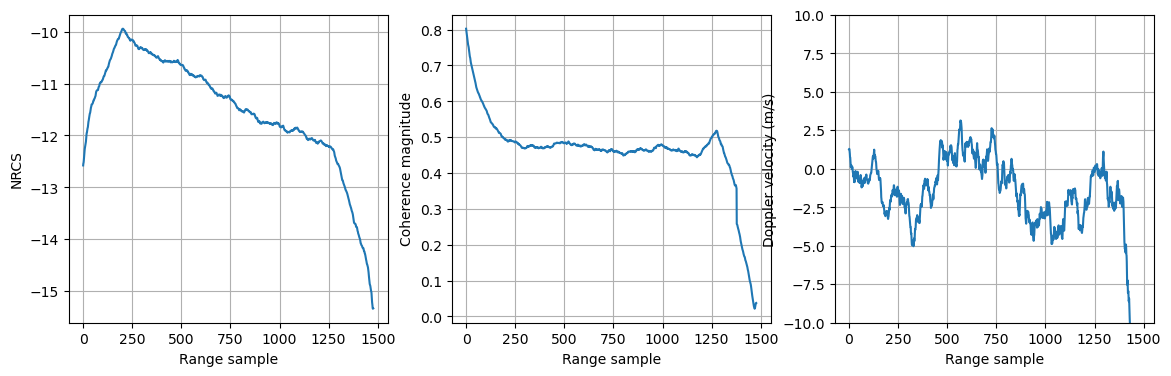

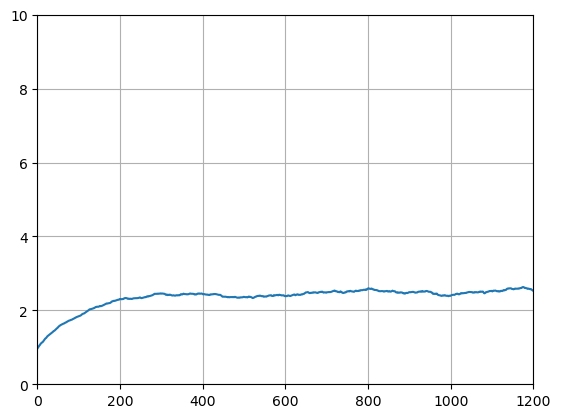

In [63]:

# nrcs = scaraw['raw_data_r'].values**2 + scaraw['raw_data_i'].values**2
# plt.figure()
# plt.plot(nrcs[1,1])
print(1e-4*scaraw.rg_sampling.values)
def dpsca_coh(scaraw, rg_ml=None):
    fs = scaraw.rg_sampling.values
    print("Sampling frequency: %f", fs)
    subpulse_length = scaraw.subpulse_length.values
    offset_smp = subpulse_length * fs
    prof =  scaraw['raw_data_r'].values + 1j * scaraw['raw_data_i'].values
    prof_corr = np.roll(prof,-int(offset_smp), axis=2)
    corr = prof_corr * np.conj(prof)
    nrcs_prof = np.abs(prof)**2
    if rg_ml is None:
        coh = np.mean(corr[:,:], axis=1) / np.sqrt(np.mean(np.abs(prof[:,:])**2, axis=1) * np.mean(np.abs(prof_corr[:,:])**2, axis=1))
        nrcs_prof = np.mean(nrcs_prof, axis=1)
    else:
        nrcs_prof = drtls.smooth(np.mean(nrcs_prof, axis=1), rg_ml, axis=1)
        corr = drtls.smooth(np.mean(corr, axis=1), rg_ml, axis=1)
        coh = corr/np.sqrt(nrcs_prof*np.roll(nrcs_prof,-int(offset_smp),axis=1))
    return nrcs_prof, coh

nrcs_prof, coh = dpsca_coh(scaraw, rg_ml=200)
fig, axs = plt.subplots(1,3, figsize=(14,4))
axs[0].plot(drtls.db(nrcs_prof[1]))
axs[0].set_xlabel('Range sample')
axs[0].set_ylabel('NRCS')
axs[1].plot(np.abs(coh[1]))
axs[1].set_xlabel('Range sample')
axs[1].set_ylabel('Coherence magnitude')
rvel = np.angle(coh)/(2*np.pi*scaraw.subpulse_length.values)*3e8/2/scaraw.f0.values
axs[2].plot(rvel[1])
axs[2].set_xlabel('Range sample')
axs[2].set_ylabel('Doppler velocity (m/s)')
axs[2].set_ylim(-10,10)
for ax in axs:
    ax.grid()
plt.figure()
nlk = 100 * 23
plt.plot(np.sqrt((1. - np.abs(coh[1]) ** 2.) / (2. * nlk * np.abs(coh[1]) ** 2.))/(2*np.pi*scaraw.subpulse_length.values)*3e8/2/scaraw.f0.values)
plt.xlim(0,1200)
plt.grid()
plt.ylim(0,10)

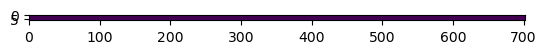

In [72]:
plt.imshow(np.isnan(np.abs(prof[1])))

In [73]:
np.sum(np.isnan(np.abs(prof)))

np.int64(0)

In [29]:
scaraw.close()

(array([ 0, -1, -2, -3, -4]), array([2.88970931e-16, 1.26820650e-12, 9.47991923e-11, 5.63819498e-12,
       0.00000000e+00]))
1.36783597917156e-25


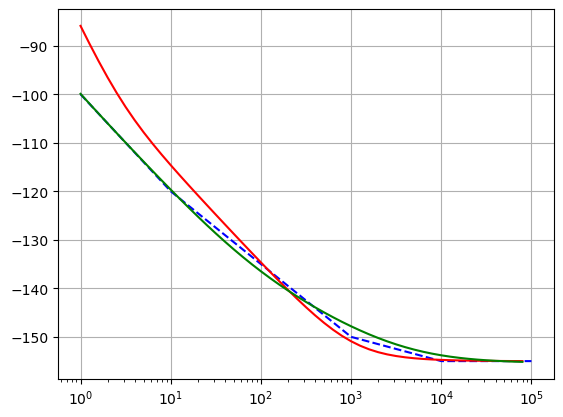

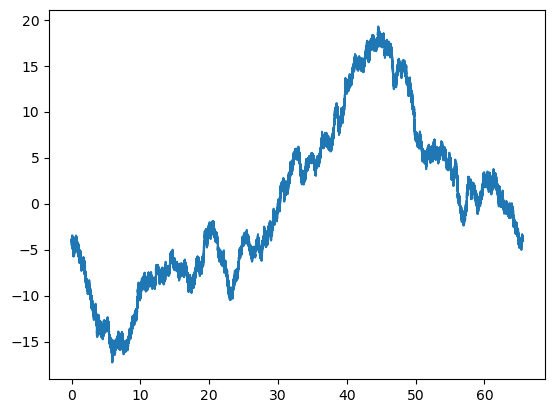

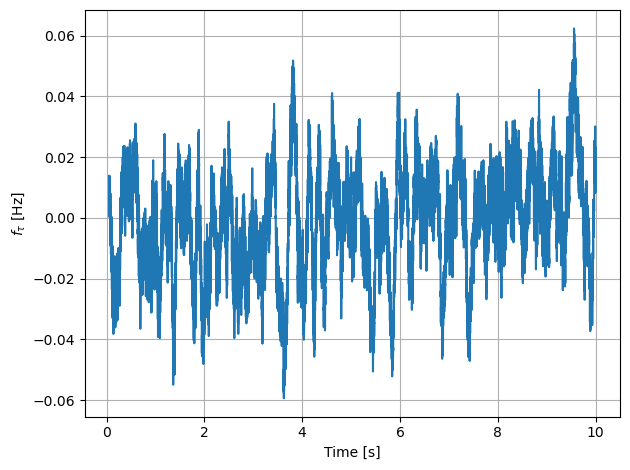

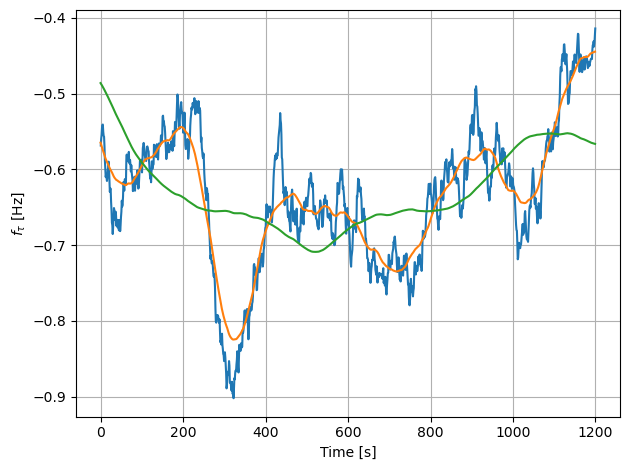

In [3]:
from drama.performance.oscillators.phasenoisesim import plot_freq
osc_coef = drosc.measured2coef(type="SAOCOM")
print(osc_coef)
pnoise, S,f = drosc.phasenoise(20, 1/2e3, osc_coef[0], osc_coef[1])
pnoise.shape
plt.figure()
plt.plot(np.arange(pnoise.size)/2e3, np.degrees(pnoise.flatten())*5.4e9/10e6)
plot_freq(pnoise*5.4e9/10e6, 1/2e3, 0.1, toff=0,xlim=(0, 10))

h_2 = (3e-11) ** 2 * 3 / (2 * np.pi ** 2 * 1e3)
print(h_2)
p, S2,f2 = drosc.phasenoise(10000, 1, -4, h_2)
pCband = p * 5.4e9
plot_freq(pCband, 1, 1, xlim=(0, 1200))
plot_freq(pCband, 1, 100, overplot=True, xlim=(0, 1200))
plot_freq(pCband, 1, 500, overplot=True, xlim=(0, 1200))

/var/folders/kk/65qkkvqd6vz1crfx4px3l5cc_8rpy_/T/ipykernel_23207/1413600141.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(f[0:int(32768/2)],10*np.log10(S[0:int(32768/2)]/f[1]))


262144

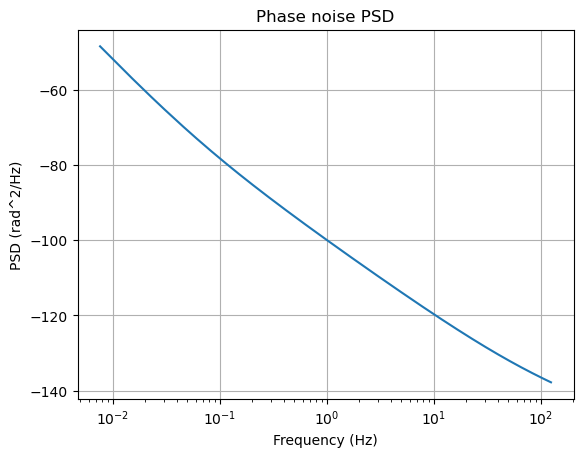

In [76]:
plt.plot(f[0:int(32768/2)],10*np.log10(S[0:int(32768/2)]/f[1]))
#plt.yscale('log')
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (rad^2/Hz)')
plt.title('Phase noise PSD')
plt.grid()
S.size

In [47]:
100e3/(3e8/2/2e6*2)

666.6666666666666